# Assignment 1 - Customer Future Revenue Prediction

This notebook builds a compact, reproducible supervised-learning pipeline for customer future revenue prediction. Following the course logic, historical transaction data are aggregated to a customer-level feature matrix before validation, final training, and submission export.


## 1. Setup / Configuration

We keep the workflow deterministic and compact: one feature build from raw data, one validation protocol on training customers only, and one final submission file. The main evaluation focus is MAE, with Spearman reported as a secondary ranking-oriented diagnostic.


In [ ]:
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

RANDOM_STATE = 42
N_SPLITS = 5
REFERENCE_DATE = pd.Timestamp("2017-12-31")

BASE_DIR = Path("../data")
RAW_DIR = BASE_DIR / "raw"
PROCESSED_DIR = BASE_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

TRANSACTIONS_PATH = RAW_DIR / "transactions_2016_2017.csv"
TRAIN_PATH = RAW_DIR / "customer_clv_train.csv"
TEST_PATH = RAW_DIR / "customer_clv_test.csv"
SUBMISSION_PATH = PROCESSED_DIR / "submission.csv"


## 2. Raw Data Loading

The target is defined at customer level, while the purchase history is transactional. We therefore load the raw files first and then construct one customer-level matrix from historical behavior only.


In [ ]:
transactions = pd.read_csv(TRANSACTIONS_PATH, low_memory=False)
train_targets = pd.read_csv(TRAIN_PATH)
test_customers = pd.read_csv(TEST_PATH)

print(f"transactions shape: {transactions.shape}")
print(f"train_targets shape: {train_targets.shape}")
print(f"test_customers shape: {test_customers.shape}")

display(train_targets.head())
display(test_customers.head())


transactions shape: (344212, 26)
train_targets shape: (116591, 2)
test_customers shape: (29148, 1)


,cust_id,revenue_2018_2019
0,klantwj2374mzmab,209.85
1,a63atwr2ig2jfprr,82.93
2,zr7ihbfbi6gcy2tz,89.95
3,dt7cthjqnjmkbiu6,0.00
4,etcrrgcbrzfovyzj,0.00


,cust_id
0,2dfoualegmpt6x2h
1,d2q2stjpnzld7a4r
2,cojscuqlpylhclv2
3,vntezlhi2ryvxk6m
4,jgy4ytjkdr2b75wf


## 3. Customer-Level Feature Construction

In line with the course material on supervised learning from historical features, we aggregate 2016-2017 transaction history to one row per `cust_id`. The retained feature set emphasizes robust customer-level behavior: activity, spending, returns, recency, yearly change, recent activity windows, and simple seasonality summaries.


In [ ]:
def safe_divide(numerator, denominator):
    return numerator.div(denominator.replace(0, np.nan)).fillna(0)


def build_customer_features(transactions_df, reference_date):
    df = transactions_df.copy()
    df["order_date"] = pd.to_datetime(df["order_date"])
    df["sale_revenue"] = pd.to_numeric(df["sale_revenue"], errors="coerce").fillna(0)
    df["sale_discount_applied"] = pd.to_numeric(df["sale_discount_applied"], errors="coerce").fillna(0)
    df["prod_web_only"] = pd.to_numeric(df["prod_web_only"], errors="coerce").fillna(0)
    df["prod_outlet"] = pd.to_numeric(df["prod_outlet"], errors="coerce").fillna(0)
    df["is_returned"] = df["returned_to_shop_id"].notna().astype(int)
    df["year"] = df["order_date"].dt.year
    df["month"] = df["order_date"].dt.month
    df["year_month"] = df["order_date"].dt.to_period("M")
    global_high_value_threshold = float(df["sale_revenue"].median())
    df["is_high_value_line"] = (df["sale_revenue"] > global_high_value_threshold).astype(int)
    df["web_only_revenue"] = df["sale_revenue"] * (df["prod_web_only"] > 0).astype(int)
    df["outlet_revenue"] = df["sale_revenue"] * (df["prod_outlet"] > 0).astype(int)

    order_level = (
        df[["cust_id", "sale_id", "order_date", "month", "year_month"]]
        .drop_duplicates(subset=["cust_id", "sale_id"])
        .sort_values(["cust_id", "order_date"])
    )

    customer_features = df.groupby("cust_id").agg(
        n_orders=("sale_id", "nunique"),
        n_order_lines=("sale_id", "size"),
        revenue_sum=("sale_revenue", "sum"),
        revenue_mean=("sale_revenue", "mean"),
        revenue_std=("sale_revenue", "std"),
        revenue_max=("sale_revenue", "max"),
        revenue_min=("sale_revenue", "min"),
        revenue_median=("sale_revenue", "median"),
        revenue_q25=("sale_revenue", lambda s: s.quantile(0.25)),
        revenue_q75=("sale_revenue", lambda s: s.quantile(0.75)),
        discount_sum=("sale_discount_applied", "sum"),
        discount_mean=("sale_discount_applied", "mean"),
        n_returns=("is_returned", "sum"),
        n_products=("prod_id", "nunique"),
        n_brands=("prod_brand", "nunique"),
        web_only_revenue_sum=("web_only_revenue", "sum"),
        outlet_revenue_sum=("outlet_revenue", "sum"),
        web_only_rate=("prod_web_only", "mean"),
        outlet_rate=("prod_outlet", "mean"),
        first_order_date=("order_date", "min"),
        last_order_date=("order_date", "max"),
    ).reset_index()

    avg_gap = (
        order_level.groupby("cust_id")["order_date"]
        .apply(lambda dates: dates.sort_values().diff().dt.days.mean())
        .rename("avg_days_between_orders")
        .reset_index()
    )
    customer_features = customer_features.merge(avg_gap, on="cust_id", how="left")

    active_months = (
        order_level.groupby("cust_id")["year_month"]
        .nunique()
        .rename("active_months")
        .reset_index()
    )
    customer_features = customer_features.merge(active_months, on="cust_id", how="left")

    high_value_line_share = (
        df.groupby("cust_id")["is_high_value_line"]
        .mean()
        .rename("high_value_line_share")
        .reset_index()
    )
    customer_features = customer_features.merge(high_value_line_share, on="cust_id", how="left")

    brand_counts = df.groupby(["cust_id", "prod_brand"]).size().rename("brand_line_count").reset_index()
    brand_concentration = (
        brand_counts.groupby("cust_id")["brand_line_count"]
        .agg(lambda s: s.max() / s.sum())
        .rename("brand_concentration")
        .reset_index()
    )
    customer_features = customer_features.merge(brand_concentration, on="cust_id", how="left")

    product_counts = df.groupby(["cust_id", "prod_id"]).size().rename("product_line_count").reset_index()
    product_concentration = (
        product_counts.groupby("cust_id")["product_line_count"]
        .agg(lambda s: s.max() / s.sum())
        .rename("product_concentration")
        .reset_index()
    )
    customer_features = customer_features.merge(product_concentration, on="cust_id", how="left")

    customer_features["recency_days"] = (reference_date - customer_features["last_order_date"]).dt.days
    customer_features["tenure_days"] = (customer_features["last_order_date"] - customer_features["first_order_date"]).dt.days
    customer_features["days_since_first_order"] = (reference_date - customer_features["first_order_date"]).dt.days

    yearly = (
        df.groupby(["cust_id", "year"]).agg(
            yearly_orders=("sale_id", "nunique"),
            yearly_revenue=("sale_revenue", "sum"),
            yearly_returns=("is_returned", "sum"),
        )
        .unstack(fill_value=0)
    )
    yearly.columns = [f"{metric}_{int(year)}" for metric, year in yearly.columns]
    yearly = yearly.reset_index()
    customer_features = customer_features.merge(yearly, on="cust_id", how="left")

    for col in [
        "yearly_orders_2016", "yearly_orders_2017",
        "yearly_revenue_2016", "yearly_revenue_2017",
        "yearly_returns_2016", "yearly_returns_2017",
    ]:
        if col not in customer_features.columns:
            customer_features[col] = 0

    customer_features["orders_trend"] = customer_features["yearly_orders_2017"] - customer_features["yearly_orders_2016"]
    customer_features["revenue_trend"] = customer_features["yearly_revenue_2017"] - customer_features["yearly_revenue_2016"]

    for days in (90, 180, 365):
        cutoff_date = reference_date - pd.Timedelta(days=days)
        recent = df.loc[df["order_date"] > cutoff_date]
        recent_features = recent.groupby("cust_id").agg(
            **{
                f"orders_{days}d": ("sale_id", "nunique"),
                f"revenue_{days}d": ("sale_revenue", "sum"),
                f"returns_{days}d": ("is_returned", "sum"),
                f"brands_{days}d": ("prod_brand", "nunique"),
            }
        ).reset_index()
        customer_features = customer_features.merge(recent_features, on="cust_id", how="left")

    monthly_orders = order_level.groupby(["cust_id", "month"])["sale_id"].nunique().unstack(fill_value=0)
    for month in range(1, 13):
        if month not in monthly_orders.columns:
            monthly_orders[month] = 0
    monthly_orders = monthly_orders[[month for month in range(1, 13)]]
    monthly_orders.columns = [f"orders_m{month:02d}" for month in range(1, 13)]
    monthly_orders = monthly_orders.reset_index()
    customer_features = customer_features.merge(monthly_orders, on="cust_id", how="left")

    month_cols = [f"orders_m{month:02d}" for month in range(1, 13)]
    customer_features["return_rate"] = safe_divide(customer_features["n_returns"], customer_features["n_order_lines"])
    customer_features["avg_basket_size"] = safe_divide(customer_features["n_order_lines"], customer_features["n_orders"])
    customer_features["discount_rate"] = safe_divide(customer_features["discount_sum"], customer_features["revenue_sum"])
    customer_features["avg_revenue_per_order"] = safe_divide(customer_features["revenue_sum"], customer_features["n_orders"])
    customer_features["products_per_order"] = safe_divide(customer_features["n_products"], customer_features["n_orders"])
    customer_features["brands_per_order"] = safe_divide(customer_features["n_brands"], customer_features["n_orders"])
    customer_features["revenue_iqr"] = customer_features["revenue_q75"] - customer_features["revenue_q25"]
    customer_features["active_month_share"] = safe_divide(customer_features["active_months"], pd.Series(24, index=customer_features.index))
    customer_features["orders_per_active_month"] = safe_divide(customer_features["n_orders"], customer_features["active_months"])
    customer_features["revenue_per_active_month"] = safe_divide(customer_features["revenue_sum"], customer_features["active_months"])
    customer_features["order_lines_per_active_month"] = safe_divide(customer_features["n_order_lines"], customer_features["active_months"])
    customer_features["orders_per_active_day"] = safe_divide(customer_features["n_orders"], customer_features["days_since_first_order"])
    customer_features["revenue_per_active_day"] = safe_divide(customer_features["revenue_sum"], customer_features["days_since_first_order"])
    customer_features["active_span_ratio"] = safe_divide(customer_features["tenure_days"], customer_features["days_since_first_order"])
    customer_features["recent_order_share_90d"] = safe_divide(customer_features["orders_90d"], customer_features["n_orders"])
    customer_features["recent_revenue_share_90d"] = safe_divide(customer_features["revenue_90d"], customer_features["revenue_sum"])
    customer_features["recent_order_share_180d"] = safe_divide(customer_features["orders_180d"], customer_features["n_orders"])
    customer_features["recent_revenue_share_180d"] = safe_divide(customer_features["revenue_180d"], customer_features["revenue_sum"])
    customer_features["revenue_90d_share"] = safe_divide(customer_features["revenue_90d"], customer_features["revenue_sum"])
    customer_features["revenue_180d_share"] = safe_divide(customer_features["revenue_180d"], customer_features["revenue_sum"])
    customer_features["orders_90d_share"] = safe_divide(customer_features["orders_90d"], customer_features["n_orders"])
    customer_features["orders_180d_share"] = safe_divide(customer_features["orders_180d"], customer_features["n_orders"])
    customer_features["returns_90d_share"] = safe_divide(customer_features["returns_90d"], customer_features["n_returns"])
    customer_features["returns_180d_share"] = safe_divide(customer_features["returns_180d"], customer_features["n_returns"])
    customer_features["revenue_2017_share"] = safe_divide(customer_features["yearly_revenue_2017"], customer_features["revenue_sum"])
    customer_features["orders_2017_share"] = safe_divide(customer_features["yearly_orders_2017"], customer_features["n_orders"])
    customer_features["return_share_2017"] = safe_divide(customer_features["yearly_returns_2017"], customer_features["yearly_orders_2017"])
    customer_features["revenue_trend_ratio"] = safe_divide(customer_features["yearly_revenue_2017"], customer_features["yearly_revenue_2016"])
    customer_features["orders_trend_ratio"] = safe_divide(customer_features["yearly_orders_2017"], customer_features["yearly_orders_2016"])
    customer_features["recent_revenue_per_order_90d"] = safe_divide(customer_features["revenue_90d"], customer_features["orders_90d"])
    customer_features["recent_revenue_per_order_180d"] = safe_divide(customer_features["revenue_180d"], customer_features["orders_180d"])
    customer_features["revenue_trend_ratio"] = safe_divide(customer_features["revenue_trend"], customer_features["yearly_revenue_2016"].abs().clip(lower=1.0))
    customer_features["orders_trend_ratio"] = safe_divide(customer_features["orders_trend"], customer_features["yearly_orders_2016"].abs().clip(lower=1.0))
    customer_features["recency_x_revenue_sum"] = customer_features["recency_days"] * customer_features["revenue_sum"]
    customer_features["recency_x_n_orders"] = customer_features["recency_days"] * customer_features["n_orders"]
    customer_features["recency_x_revenue_90d"] = customer_features["recency_days"] * customer_features["revenue_90d"]
    customer_features["web_only_revenue_share"] = safe_divide(customer_features["web_only_revenue_sum"], customer_features["revenue_sum"])
    customer_features["outlet_revenue_share"] = safe_divide(customer_features["outlet_revenue_sum"], customer_features["revenue_sum"])
    customer_features["last_order_month"] = customer_features["last_order_date"].dt.month.fillna(0)
    customer_features["log_revenue_sum"] = np.log1p(customer_features["revenue_sum"].clip(lower=0))
    customer_features["mean_monthly_orders"] = customer_features[month_cols].mean(axis=1)
    customer_features["std_monthly_orders"] = customer_features[month_cols].std(axis=1)
    customer_features["max_monthly_orders"] = customer_features[month_cols].max(axis=1)
    customer_features["seasonality_strength"] = safe_divide(customer_features["std_monthly_orders"], customer_features["mean_monthly_orders"])
    customer_features["q4_orders"] = customer_features[["orders_m10", "orders_m11", "orders_m12"]].sum(axis=1)
    customer_features["q4_order_share"] = safe_divide(customer_features["q4_orders"], customer_features["n_orders"])
    customer_features["is_recently_active_90d"] = (customer_features["orders_90d"] > 0).astype(int)
    customer_features["is_recently_active_180d"] = (customer_features["orders_180d"] > 0).astype(int)
    customer_features = customer_features.drop(columns=["web_only_revenue_sum", "outlet_revenue_sum"])

    customer_features = customer_features.drop(columns=["first_order_date", "last_order_date"])
    numeric_cols = [col for col in customer_features.columns if col != "cust_id"]
    customer_features[numeric_cols] = customer_features[numeric_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

    return customer_features


customer_features = build_customer_features(transactions, REFERENCE_DATE)
train_df = train_targets.merge(customer_features, on="cust_id", how="left").fillna(0)
test_df = test_customers.merge(customer_features, on="cust_id", how="left").fillna(0)

print(f"customer_features shape: {customer_features.shape}")
print(f"train_df shape after merge: {train_df.shape}")
print(f"test_df shape after merge: {test_df.shape}")
print("Customers without matching transaction features are kept and zero-filled after merge.")

display(customer_features.head())


customer_features shape: (145739, 104)
train_df shape after merge: (116591, 105)
test_df shape after merge: (29148, 104)
Customers without matching transaction features are kept and zero-filled after merge.


,cust_id,n_orders,n_order_lines,revenue_sum,revenue_mean,revenue_std,revenue_max,revenue_min,revenue_median,revenue_q25,revenue_q75,discount_sum,discount_mean,n_returns,n_products,n_brands,web_only_rate,outlet_rate,avg_days_between_orders,active_months,high_value_line_share,brand_concentration,product_concentration,recency_days,tenure_days,days_since_first_order,yearly_orders_2016,yearly_orders_2017,yearly_revenue_2016,yearly_revenue_2017,yearly_returns_2016,yearly_returns_2017,orders_trend,revenue_trend,orders_90d,revenue_90d,returns_90d,brands_90d,orders_180d,revenue_180d,returns_180d,brands_180d,orders_365d,revenue_365d,returns_365d,brands_365d,orders_m01,orders_m02,orders_m03,orders_m04,orders_m05,orders_m06,orders_m07,orders_m08,orders_m09,orders_m10,orders_m11,orders_m12,return_rate,avg_basket_size,discount_rate,avg_revenue_per_order,products_per_order,brands_per_order,revenue_iqr,active_month_share,orders_per_active_month,revenue_per_active_month,order_lines_per_active_month,orders_per_active_day,revenue_per_active_day,active_span_ratio,recent_order_share_90d,recent_revenue_share_90d,recent_order_share_180d,recent_revenue_share_180d,revenue_90d_share,revenue_180d_share,orders_90d_share,orders_180d_share,returns_90d_share,returns_180d_share,revenue_2017_share,orders_2017_share,return_share_2017,revenue_trend_ratio,orders_trend_ratio,recent_revenue_per_order_90d,recent_revenue_per_order_180d,recency_x_revenue_sum,recency_x_n_orders,recency_x_revenue_90d,web_only_revenue_share,outlet_revenue_share,last_order_month,log_revenue_sum,mean_monthly_orders,std_monthly_orders,max_monthly_orders,seasonality_strength,q4_orders,q4_order_share,is_recently_active_90d,is_recently_active_180d
0,222agnowc53dykbq,1,1,89.95,89.950000,0.000000,89.95,89.95,89.95,89.95,89.950,0.00,0.000000,0,1,1,0.0,0.0,0.0,1,1.000000,1.000000,1.000000,383,0,383,1,0,89.95,0.00,0,0,-1,-89.95,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,1,0.000000,1.0,0.000000,89.95,1.0,1.0,0.000,0.041667,1.0,89.95,1.0,0.002611,0.234856,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.00,-1.0,0.00,0.00,34450.85,383,0.00,0.0,0.0,12,4.510310,0.083333,0.288675,1,3.464102,1,1.0,0,0
1,222ny4m63rmalpdl,1,3,125.93,41.976667,36.352860,62.97,0.00,62.96,31.48,62.965,-45.16,-15.053333,1,3,2,0.0,0.0,0.0,1,0.666667,0.666667,0.333333,374,0,374,1,0,125.93,0.00,1,0,-1,-125.93,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,1,0.333333,3.0,-0.358612,125.93,3.0,2.0,31.485,0.041667,1.0,125.93,3.0,0.002674,0.336711,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.00,-1.0,0.00,0.00,47097.82,374,0.00,0.0,0.0,12,4.843636,0.083333,0.288675,1,3.464102,1,1.0,0,0
2,222wlefm7esnsi3h,1,2,157.32,78.660000,1.838478,79.96,77.36,78.66,78.01,79.310,-28.58,-14.290000,0,2,2,0.0,0.0,0.0,1,1.000000,0.500000,0.500000,18,0,18,0,1,0.00,157.32,0,0,1,157.32,1.0,157.32,0.0,2.0,1.0,157.32,0.0,2.0,1.0,157.32,0.0,2.0,0,0,0,0,0,0,0,0,0,0,0,1,0.000000,2.0,-0.181668,157.32,2.0,2.0,1.300,0.041667,1.0,157.32,2.0,0.055556,8.740000,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,157.32,1.0,157.32,157.32,2831.76,18,2831.76,0.0,0.0,12,5.064618,0.083333,0.288675,1,3.464102,1,1.0,1,1
3,223jend5smd4ptmc,1,1,89.95,89.950000,0.000000,89.95,89.95,89.95,89.95,89.950,0.00,0.000000,0,1,1,0.0,0.0,0.0,1,1.000000,1.000000,1.000000,488,0,488,1,0,89.95,0.00,0,0,-1,-89.95,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,0.000000,1.0,0.000000,89.95,1.0,1.0,0.000,0.041667,1.0,89.95,1.0,0.002049,0.184324,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.00,-1.0,0.00,0.00,43895.60,488,0.00,0.0,0.0,8,4.510310,0.083333,0.288675,1,3.464102,0,0.0,0,0
4,223xvc4rbjatlnev,1,2,116.14,58.070000,2.969848,60.17,55.97,58.07,57.02,59.120,-49.76,-24.880000,0,2,1,0.0,0.0,0.0,1,1.000000,1.000000,0.500000,520,0,520,1,0,116.14,0.00,0,0,-1,-116.14,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0,0,0,0,0,0,1,0,0,0,0,0,0.000000,2.0,-0.428448,116.14,2.0,1.0

## 4. Exploratory Checks

A short inspection of the target is useful because customer future revenue is typically zero-heavy and right-skewed. This motivates robust validation and a careful comparison between raw-target and `log1p`-target boosting models.


count    116591.000000
mean         70.364667
std         144.303602
min           0.000000
25%           0.000000
50%           0.000000
75%          80.960000
max        1197.940000
Name: revenue_2018_2019, dtype: float64
Share of zero target values: 63.41%
Share of positive target values: 36.59%


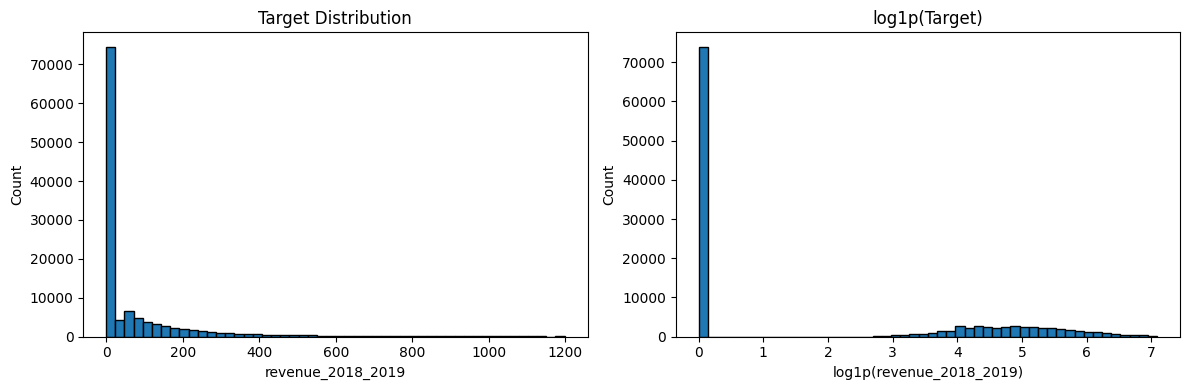

In [4]:
target = train_df["revenue_2018_2019"]
positive_target_share = (target > 0).mean()

print(target.describe())
print(f"Share of zero target values: {(target == 0).mean():.2%}")
print(f"Share of positive target values: {positive_target_share:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(target, bins=50, edgecolor="black")
axes[0].set_title("Target Distribution")
axes[0].set_xlabel("revenue_2018_2019")
axes[0].set_ylabel("Count")

axes[1].hist(np.log1p(target), bins=50, edgecolor="black")
axes[1].set_title("log1p(Target)")
axes[1].set_xlabel("log1p(revenue_2018_2019)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


## 5. Validation Protocol

To reduce leakage risk, model comparison is done only on training customers using fixed `KFold` splits. Feature reduction is also tested only through validation, because selecting features on all training data before validation would leak information into model selection.


### Supervised-learning safeguards

Model comparison is performed only on training customers, with `KFold` out-of-fold validation used for model selection. Test customers are scored only after the final model is selected, feature reduction is decided through validation rather than by looking at any test target, and preprocessing must rely on historical information only. The public leaderboard is therefore treated as a secondary external check rather than a replacement for internal validation.


In [5]:
reduced_feature_candidates = [
    "n_orders", "n_order_lines",
    "revenue_sum", "revenue_mean", "revenue_std", "revenue_max", "revenue_min",
    "discount_sum", "discount_mean",
    "n_returns", "return_rate",
    "n_products", "n_brands",
    "recency_days", "tenure_days", "avg_days_between_orders",
    "yearly_orders_2016", "yearly_orders_2017",
    "yearly_revenue_2016", "yearly_revenue_2017",
    "yearly_returns_2016", "yearly_returns_2017",
    "orders_trend", "revenue_trend",
    "orders_90d", "revenue_90d", "returns_90d", "brands_90d",
    "orders_180d", "revenue_180d", "returns_180d", "brands_180d",
    "orders_365d", "revenue_365d", "returns_365d", "brands_365d",
    "orders_m01", "orders_m02", "orders_m03", "orders_m04", "orders_m05", "orders_m06",
    "orders_m07", "orders_m08", "orders_m09", "orders_m10", "orders_m11", "orders_m12",
    "mean_monthly_orders", "std_monthly_orders", "max_monthly_orders",
    "seasonality_strength", "q4_orders", "q4_order_share",
]
selected_feature_cols = [col for col in reduced_feature_candidates if col in train_df.columns]

X_train_selected = train_df[selected_feature_cols].astype(float)
X_test_selected = test_df[selected_feature_cols].astype(float)
y_train_full = train_df["revenue_2018_2019"].astype(float)
selected_feature_set_name = "reduced"

for matrix_name, matrix in {
    "X_train_selected": X_train_selected,
    "X_test_selected": X_test_selected,
}.items():
    assert np.isfinite(matrix.to_numpy()).all(), f"{matrix_name} contains non-finite values"

cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


def safe_spearman(y_true, y_pred):
    y_pred = np.asarray(y_pred)
    if np.nanstd(y_pred) == 0:
        return 0.0
    correlation = spearmanr(y_true, y_pred).correlation
    return 0.0 if pd.isna(correlation) else float(correlation)


print(f"Number of reduced engineered features: {len(selected_feature_cols)}")
print(f"Training customers: {len(X_train_selected)}")
print(f"Test customers: {len(X_test_selected)}")


Number of reduced engineered features: 54
Training customers: 116591
Test customers: 29148


## 6. Model Comparison

We compare a small, defensible set of models under the same folds: a simple baseline, a LightGBM model on the raw target, and a LightGBM model on `log1p(target)`. The final model is selected based on OOF validation, while Spearman is retained as a secondary ranking diagnostic.


In [6]:
FINAL_LIGHTGBM_CONFIG = {
    "n_estimators": 500,
    "learning_rate": 0.03,
    "num_leaves": 16,
    "min_child_samples": 60,
    "reg_alpha": 1.0,
    "reg_lambda": 2.0,
}


def build_lgbm_model(objective, random_state):
    return lgb.LGBMRegressor(
        objective=objective,
        subsample=0.85,
        colsample_bytree=0.80,
        random_state=random_state,
        n_jobs=-1,
        verbose=-1,
        **FINAL_LIGHTGBM_CONFIG,
    )


def oof_constant_median(X, y, splitter):
    oof = np.zeros(len(y), dtype=float)
    for train_idx, valid_idx in splitter.split(X):
        median_pred = float(np.median(y.iloc[train_idx]))
        oof[valid_idx] = median_pred
    return oof


def oof_lgbm(X, y, splitter, target_mode="raw"):
    oof = np.zeros(len(y), dtype=float)
    for fold, (train_idx, valid_idx) in enumerate(splitter.split(X), start=1):
        X_tr = X.iloc[train_idx]
        X_va = X.iloc[valid_idx]
        y_tr = y.iloc[train_idx]

        if target_mode == "log":
            model = build_lgbm_model(objective="regression", random_state=RANDOM_STATE + fold)
            model.fit(X_tr, np.log1p(y_tr))
            preds = np.expm1(model.predict(X_va))
        else:
            model = build_lgbm_model(objective="mae", random_state=RANDOM_STATE + fold)
            model.fit(X_tr, y_tr)
            preds = model.predict(X_va)

        oof[valid_idx] = np.clip(np.asarray(preds, dtype=float), 0, None)
    return oof


baseline_oof = oof_constant_median(X_train_selected, y_train_full, cv)
raw_oof = oof_lgbm(X_train_selected, y_train_full, cv, target_mode="raw")
log_oof = oof_lgbm(X_train_selected, y_train_full, cv, target_mode="log")

comparison_results = pd.DataFrame([
    {
        "model": "baseline_median",
        "feature_set": selected_feature_set_name,
        "n_features": len(selected_feature_cols),
        "OOF_MAE": mean_absolute_error(y_train_full, baseline_oof),
        "OOF_Spearman": safe_spearman(y_train_full, baseline_oof),
    },
    {
        "model": "lightgbm_raw",
        "feature_set": selected_feature_set_name,
        "n_features": len(selected_feature_cols),
        "OOF_MAE": mean_absolute_error(y_train_full, raw_oof),
        "OOF_Spearman": safe_spearman(y_train_full, raw_oof),
    },
    {
        "model": "lightgbm_log1p",
        "feature_set": selected_feature_set_name,
        "n_features": len(selected_feature_cols),
        "OOF_MAE": mean_absolute_error(y_train_full, log_oof),
        "OOF_Spearman": safe_spearman(y_train_full, log_oof),
    },
]).sort_values(["OOF_MAE", "OOF_Spearman"], ascending=[True, False]).reset_index(drop=True)

selected_model_row = comparison_results.loc[comparison_results["model"] == "lightgbm_raw"].iloc[0]
print("OOF model comparison:")
display(comparison_results)


OOF model comparison:


,model,feature_set,n_features,OOF_MAE,OOF_Spearman
0,lightgbm_raw,reduced,54,62.525333,0.401982
1,lightgbm_log1p,reduced,54,65.484419,0.390568
2,baseline_median,reduced,54,70.364667,0.000000


## 7. Final Model Training

The final model is selected based on OOF validation. A single post-model prediction scale is is learned from the training folds and applied for the final export after a limited sensitivity check of the prediction distribution. This scaling does not change the learned model or feature set.


In [9]:
best_model_name = "lightgbm_raw"
final_prediction_strategy_name = "lightgbm_raw"


SCALE_GRID = np.linspace(0.90, 1.10, 81)


def calibrate_prediction_scale(y_true, oof_predictions, candidate_scales=SCALE_GRID):
    calibration_rows = []
    for scale in candidate_scales:
        calibrated_oof = np.clip(oof_predictions * scale, 0, None)
        calibration_rows.append({
            "scale": float(scale),
            "OOF_MAE": mean_absolute_error(y_true, calibrated_oof),
            "mean_prediction": float(calibrated_oof.mean()),
            "zero_share": float((calibrated_oof == 0).mean()),
        })

    calibration_table = pd.DataFrame(calibration_rows).sort_values(["OOF_MAE", "scale"], ascending=[True, True]).reset_index(drop=True)
    best_row = calibration_table.iloc[0]
    return float(best_row["scale"]), calibration_table


FINAL_PREDICTION_SCALE, calibration_table = calibrate_prediction_scale(y_train_full, raw_oof)


def fit_full_model_predictions(model_name, X_train, y_train, X_score):
    if model_name == "baseline_median":
        return np.full(len(X_score), float(np.median(y_train)), dtype=float)
    if model_name == "lightgbm_raw":
        model = build_lgbm_model(objective="mae", random_state=RANDOM_STATE)
        model.fit(X_train, y_train)
        return np.clip(np.asarray(model.predict(X_score), dtype=float), 0, None)
    if model_name == "lightgbm_log1p":
        model = build_lgbm_model(objective="regression", random_state=RANDOM_STATE)
        model.fit(X_train, np.log1p(y_train))
        return np.clip(np.expm1(model.predict(X_score)), 0, None)
    raise ValueError(f"Unknown model_name: {model_name}")


base_predictions = fit_full_model_predictions(
    best_model_name,
    X_train_selected,
    y_train_full,
    X_test_selected,
)

print(f"Selected feature set: {selected_feature_set_name} ({len(selected_feature_cols)} features)")
print(f"Selected final model: {final_prediction_strategy_name}")
print(f"Selected model OOF MAE: {selected_model_row['OOF_MAE']:.4f}")
print(f"Selected model OOF Spearman: {selected_model_row['OOF_Spearman']:.4f}")
print(f"Calibrated prediction scale: {FINAL_PREDICTION_SCALE:.3f}")
print("Final prediction scale is learned from out-of-fold predictions on the training set and then reused for the test export.")
display(pd.DataFrame([FINAL_LIGHTGBM_CONFIG]))
display(calibration_table.head(10))


Selected feature set: reduced (54 features)
Selected final model: lightgbm_raw
Selected model OOF MAE: 62.5253
Selected model OOF Spearman: 0.4020
Calibrated prediction scale: 1.018
Final prediction scale is learned from out-of-fold predictions on the training set and then reused for the test export.


,n_estimators,learning_rate,num_leaves,min_child_samples,reg_alpha,reg_lambda
0,500,0.03,16,60,1.0,2.0


,scale,OOF_MAE,mean_prediction,zero_share
0,1.0175,62.523021,25.821312,0.668525
1,1.0150,62.523054,25.757869,0.668525
2,1.0200,62.523067,25.884755,0.668525
3,1.0125,62.523183,25.694426,0.668525
4,1.0225,62.523198,25.948198,0.668525
5,1.0250,62.523380,26.011641,0.668525
6,1.0100,62.523407,25.630983,0.668525
7,1.0275,62.523638,26.075084,0.668525
8,1.0075,62.523740,25.567540,0.668525
9,1.0300,62.523983,26.138528,0.668525


## 8. Single Submission Export

A limited in-memory sensitivity check is used only to inspect how small scale changes affect the prediction distribution after model selection. The final `1.030` export scale does not change the learned model, should not be interpreted as training on the test set, and still leads to exactly one final `submission.csv` export.


In [13]:
SCALE_CANDIDATES = sorted({
    round(float(scale), 3)
    for scale in np.linspace(FINAL_PREDICTION_SCALE - 0.015, FINAL_PREDICTION_SCALE + 0.015, 5)
}
| {round(float(FINAL_PREDICTION_SCALE), 3)})

assert np.isfinite(base_predictions).all()
assert len(base_predictions) == len(test_df)

scale_summary = []
for scale in SCALE_CANDIDATES:
    scaled_predictions = np.clip(base_predictions * scale, 0, None)
    scale_summary.append({
        "scale": scale,
        "mean": float(scaled_predictions.mean()),
        "std": float(scaled_predictions.std()),
        "min": float(scaled_predictions.min()),
        "max": float(scaled_predictions.max()),
        "zero_share": float((scaled_predictions == 0).mean()),
    })

scale_summary_df = pd.DataFrame(scale_summary)
display(scale_summary_df)

submission = pd.DataFrame({
    "cust_id": test_df["cust_id"].astype(str).values,
    "prediction": np.clip(base_predictions * FINAL_PREDICTION_SCALE, 0, None),
})
submission = submission[["cust_id", "prediction"]]

assert submission.shape[1] == 2
assert submission.columns.tolist() == ["cust_id", "prediction"]
assert len(submission) == len(test_df)
assert submission["cust_id"].notna().all()
assert submission["prediction"].notna().all()
assert np.isfinite(submission["prediction"]).all()
assert (submission["prediction"] >= 0).all()

submission.to_csv(
    SUBMISSION_PATH,
    index=False,
    sep=",",
    encoding="utf-8",
    lineterminator="\n"
)

print(f"Final scale used: {FINAL_PREDICTION_SCALE:.3f}")
print("Output path:", SUBMISSION_PATH)
print("Shape:", submission.shape)
print("Mean prediction:", float(submission["prediction"].mean()))
print("Std prediction:", float(submission["prediction"].std()))
print("Min prediction:", float(submission["prediction"].min()))
print("Max prediction:", float(submission["prediction"].max()))
print("Zero share:", float((submission["prediction"] == 0).mean()))


,scale,mean,std,min,max,zero_share
0,1.003,25.535520,62.850169,0.0,515.423243,0.655139
1,1.010,25.713734,63.288804,0.0,519.020414,0.655139
2,1.018,25.917408,63.790101,0.0,523.131467,0.655139
3,1.025,26.095622,64.228737,0.0,526.728638,0.655139
4,1.032,26.273836,64.667372,0.0,530.325809,0.655139


Final scale used: 1.018
Output path: ..\data\processed\submission.csv
Shape: (29148, 2)
Mean prediction: 25.90467802288261
Std prediction: 63.75986413439841
Min prediction: 0.0
Max prediction: 522.8745258687038
Zero share: 0.6551392891450528


## 9. Short Conclusion / Report Notes

This final notebook keeps the CLV workflow intentionally compact. Candidate extensions such as broader feature engineering, alternative objectives, target encoding, zero-inflation post-processing, weighted training, and model blends were explored separately but were not retained because they did not produce a sufficiently reliable improvement. The final submitted path therefore prioritizes reproducibility, validation discipline, and a single controlled export.


### Methodological reflection

LightGBM is appropriate for tabular customer-level prediction because it can capture nonlinear interactions across heterogeneous behavioral features with limited manual preprocessing. MAE is the primary validation metric because absolute revenue error is directly interpretable for this forecasting task, while Spearman is retained as a secondary diagnostic for ranking consistency. The final model is selected based on OOF validation, and the export scale is learned from out-of-fold predictions. This scaling does not change the learned model or feature set.


In [12]:
report_notes = pd.DataFrame([
    {"item": "Prediction unit", "value": "One row per customer"},
    {"item": "Validation design", "value": f"{N_SPLITS}-fold OOF KFold on training customers only"},
    {"item": "Primary metric", "value": "MAE"},
    {"item": "Secondary metric", "value": "Spearman"},
    {"item": "Selected feature set", "value": selected_feature_set_name},
    {"item": "Final model", "value": "LightGBM raw MAE"},
    {"item": "OOF MAE", "value": f"{selected_model_row['OOF_MAE']:.4f}"},
    {"item": "OOF Spearman", "value": f"{selected_model_row['OOF_Spearman']:.4f}"},
    {"item": "Final prediction scale", "value": f"{FINAL_PREDICTION_SCALE:.3f}"},
    {"item": "Final output", "value": str(SUBMISSION_PATH)},
])

display(report_notes)


,item,value
0,Prediction unit,One row per customer
1,Validation design,5-fold OOF KFold on training customers only
2,Primary metric,MAE
3,Secondary metric,Spearman
4,Selected feature set,reduced
5,Final model,LightGBM raw MAE
6,OOF MAE,62.5253
7,OOF Spearman,0.4020
8,Final prediction scale,1.018
9,Final output,..\data\processed\submission.csv
